# XGBoost Fraud Detection Model — Training Notebook

This notebook trains an `XGBClassifier` on the processed fraud-detection dataset,
evaluates it, and saves the model, metrics, and figures.

Run the cells top to bottom. In Google Colab, run the **Setup** cell first to install
`xgboost` (not preinstalled in all Colab images) and optionally mount Drive.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

print("Imports OK")

Imports OK


## 1. Configure paths

Update `WORKSPACE_ROOT` below if your workspace isn't auto-detected (e.g. if you mounted
Google Drive, point it at the Drive folder containing `data/processed/...`).

In [2]:
def find_workspace_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for path in [current, *current.parents]:
        if (path / "data" / "processed" / "baseline_modeling_dataset.csv.gz").exists():
            return path

    return current


WORKSPACE_ROOT = find_workspace_root()

# --- If auto-detection doesn't find your dataset (common in Colab), set it manually: ---
# WORKSPACE_ROOT = Path("/content/drive/MyDrive/your-project-folder")

DATASET_FILE = WORKSPACE_ROOT / "data" / "processed" / "baseline_modeling_dataset.csv.gz"
FIGURES_DIR = WORKSPACE_ROOT / "reports" / "figures"
REPORTS_DIR = WORKSPACE_ROOT / "reports" / "model_reports"
MODEL_DIR = WORKSPACE_ROOT / "ml" / "model_artifacts"
DOCS_DIR = WORKSPACE_ROOT / "docs" / "modeling"
METRICS_FILE = REPORTS_DIR / "xgboost_model_metrics.csv"
CLASSIFICATION_REPORT_FILE = REPORTS_DIR / "xgboost_classification_report.txt"
MODEL_FILE = MODEL_DIR / "xgboost_fraud_model.joblib"
RANDOM_STATE = 42
TEST_SIZE = 0.2

print(f"WORKSPACE_ROOT: {WORKSPACE_ROOT}")
print(f"DATASET_FILE:   {DATASET_FILE}")
print(f"Dataset exists: {DATASET_FILE.exists()}")

WORKSPACE_ROOT: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai
DATASET_FILE:   C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\data\processed\baseline_modeling_dataset.csv.gz
Dataset exists: True


In [3]:
def create_output_directories() -> None:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    DOCS_DIR.mkdir(parents=True, exist_ok=True)


create_output_directories()
print("Output directories ready:")
for d in [FIGURES_DIR, REPORTS_DIR, MODEL_DIR, DOCS_DIR]:
    print(f"  - {d}")

Output directories ready:
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\ml\model_artifacts
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\docs\modeling


## 2. Load the dataset

In [4]:
def load_dataset() -> tuple[pd.DataFrame, pd.Series]:
    if not DATASET_FILE.exists():
        raise FileNotFoundError(
            f"Processed dataset not found: {DATASET_FILE}. "
            "Run the baseline feature dataset build script first."
        )

    df = pd.read_csv(DATASET_FILE)
    target = df["isFraud"]
    features = df.drop(columns=["isFraud"])
    return features, target


features, target = load_dataset()
print(f"Features shape: {features.shape}")
print(f"Target shape:   {target.shape}")
print(f"Fraud rate:     {target.mean():.4%}")
features.head()

Features shape: (590540, 81)
Target shape:   (590540,)
Fraud rate:     3.4990%


,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,...,DeviceInfo,has_identity,TransactionAmt_log,transaction_hour,transaction_day,P_emaildomain_missing,R_emaildomain_missing,email_domain_match,card_missing_count,address_missing_count
0,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,87.0,...,missing,0,4.241327,0,1,1,1,-1,1,0
1,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,...,missing,0,3.401197,0,1,0,1,-1,0,0
2,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,...,missing,0,4.094345,0,1,0,1,-1,0,0
3,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,...,missing,0,3.931826,0,1,0,1,-1,0,0
4,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,...,rare,1,3.931826,0,1,0,1,-1,0,0


## 3. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target,
)

print(f"X_train: {X_train.shape}   y_train fraud rate: {y_train.mean():.4%}")
print(f"X_test:  {X_test.shape}   y_test fraud rate:  {y_test.mean():.4%}")

X_train: (472432, 81)   y_train fraud rate: 3.4989%
X_test:  (118108, 81)   y_test fraud rate:  3.4993%


## 4. Build the preprocessing pipeline

Note: unlike the baseline linear model, numeric features are **not scaled** here —
tree-based models like XGBoost don't need standardization, only imputation.

In [6]:
def build_preprocessing_pipeline(features: pd.DataFrame) -> ColumnTransformer:
    numeric_columns = features.select_dtypes(include=["number"]).columns.tolist()
    categorical_columns = features.select_dtypes(include=["object"]).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                ),
            ),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_columns),
            ("categorical", categorical_pipeline, categorical_columns),
        ]
    )
    return preprocessor


preprocessor_preview = build_preprocessing_pipeline(features)
numeric_cols = features.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = features.select_dtypes(include=["object"]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (63): ['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V44', 'V45', 'V52', 'V86', 'V87', 'V147', 'V149', 'V156', 'V158', 'V170', 'V188', 'V189', 'V200', 'V201', 'V228', 'V242', 'V244', 'V246', 'V257', 'V258', 'has_identity', 'TransactionAmt_log', 'transaction_hour', 'transaction_day', 'P_emaildomain_missing', 'R_emaildomain_missing', 'email_domain_match', 'card_missing_count', 'address_missing_count']
Categorical columns (18): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_31', 'id_33', 'DeviceType', 'DeviceInfo']


## 5. Compute class imbalance weight (`scale_pos_weight`)

In [7]:
def calculate_scale_pos_weight(y_train: pd.Series) -> float:
    negative_count = (y_train == 0).sum()
    positive_count = (y_train == 1).sum()
    return negative_count / positive_count


scale_pos_weight = calculate_scale_pos_weight(y_train)
print(f"Negative (non-fraud) count: {(y_train == 0).sum()}")
print(f"Positive (fraud) count:     {(y_train == 1).sum()}")
print(f"scale_pos_weight:           {scale_pos_weight:.3f}")

Negative (non-fraud) count: 455902
Positive (fraud) count:     16530
scale_pos_weight:           27.580


## 6. Build the full model pipeline (preprocessing + XGBoost classifier)

In [8]:
def build_model_pipeline(features: pd.DataFrame, scale_pos_weight: float) -> Pipeline:
    preprocessor = build_preprocessing_pipeline(features)
    classifier = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier),
        ]
    )
    return model_pipeline


model_pipeline = build_model_pipeline(features, scale_pos_weight)
model_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 7. Train the model

This may take a few minutes depending on dataset size and Colab runtime.

In [9]:
print("Training XGBoost model. This may take several minutes...")
model_pipeline.fit(X_train, y_train)
print("Training complete.")

Training XGBoost model. This may take several minutes...
Training complete.


In [10]:
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]
print("Predictions generated on test set.")
print(f"Predicted fraud rate: {y_pred.mean():.4%}")

Predictions generated on test set.
Predicted fraud rate: 15.6865%


## 8. Evaluate — metrics table

In [11]:
def calculate_metrics(
    y_test: pd.Series,
    y_pred: pd.Series,
    y_proba: pd.Series,
) -> pd.DataFrame:
    metrics = [
        {
            "metric": "accuracy",
            "value": accuracy_score(y_test, y_pred),
        },
        {
            "metric": "precision",
            "value": precision_score(y_test, y_pred, zero_division=0),
        },
        {
            "metric": "recall",
            "value": recall_score(y_test, y_pred, zero_division=0),
        },
        {
            "metric": "f1_score",
            "value": f1_score(y_test, y_pred, zero_division=0),
        },
        {
            "metric": "roc_auc",
            "value": roc_auc_score(y_test, y_proba),
        },
        {
            "metric": "average_precision_pr_auc",
            "value": average_precision_score(y_test, y_proba),
        },
    ]
    return pd.DataFrame(metrics)


metrics_df = calculate_metrics(y_test, y_pred, y_proba)
metrics_df.to_csv(METRICS_FILE, index=False)
print(f"Metrics saved to: {METRICS_FILE}")
metrics_df

Metrics saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\xgboost_model_metrics.csv


,metric,value
0,accuracy,0.863498
1,precision,0.176445
2,recall,0.790951
3,f1_score,0.288526
4,roc_auc,0.904650
5,average_precision_pr_auc,0.535844


## 9. Classification report

In [12]:
def save_classification_report(y_test: pd.Series, y_pred: pd.Series) -> str:
    report = classification_report(
        y_test,
        y_pred,
        target_names=["non_fraud", "fraud"],
        zero_division=0,
    )
    CLASSIFICATION_REPORT_FILE.write_text(report, encoding="utf-8")
    return report


report_text = save_classification_report(y_test, y_pred)
print(f"Classification report saved to: {CLASSIFICATION_REPORT_FILE}\n")
print(report_text)

Classification report saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\xgboost_classification_report.txt

              precision    recall  f1-score   support

   non_fraud       0.99      0.87      0.92    113975
       fraud       0.18      0.79      0.29      4133

    accuracy                           0.86    118108
   macro avg       0.58      0.83      0.61    118108
weighted avg       0.96      0.86      0.90    118108



## 10. Confusion matrix

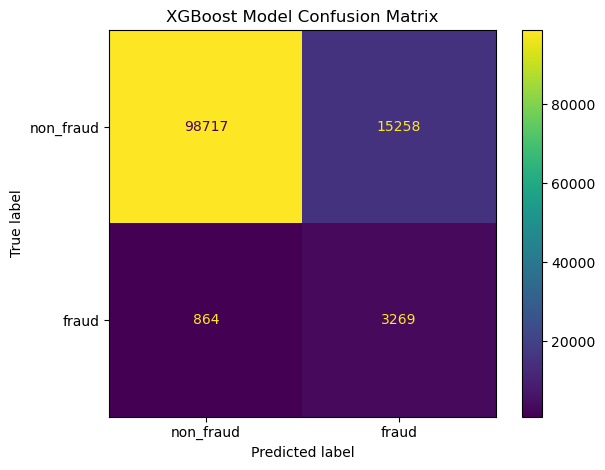

Confusion matrix figure saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\xgboost_confusion_matrix.png


In [13]:
def plot_confusion_matrix(y_test: pd.Series, y_pred: pd.Series) -> None:
    matrix = confusion_matrix(y_test, y_pred)
    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["non_fraud", "fraud"],
    )
    display.plot(values_format="d")
    plt.title("XGBoost Model Confusion Matrix")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "xgboost_confusion_matrix.png")
    plt.show()


plot_confusion_matrix(y_test, y_pred)
print(f"Confusion matrix figure saved to: {FIGURES_DIR / 'xgboost_confusion_matrix.png'}")

## 11. Precision-recall curve

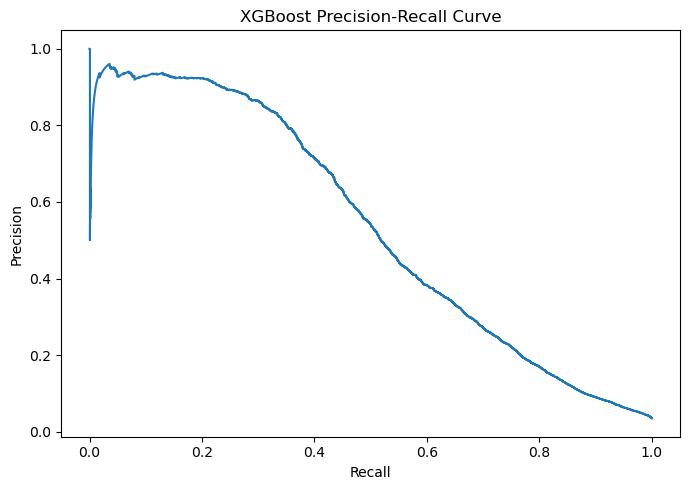

Precision-recall curve saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\xgboost_precision_recall_curve.png


In [14]:
def plot_precision_recall_curve(y_test: pd.Series, y_proba: pd.Series) -> None:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision)
    plt.title("XGBoost Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "xgboost_precision_recall_curve.png")
    plt.show()


plot_precision_recall_curve(y_test, y_proba)
print(f"Precision-recall curve saved to: {FIGURES_DIR / 'xgboost_precision_recall_curve.png'}")

## 12. Feature importance

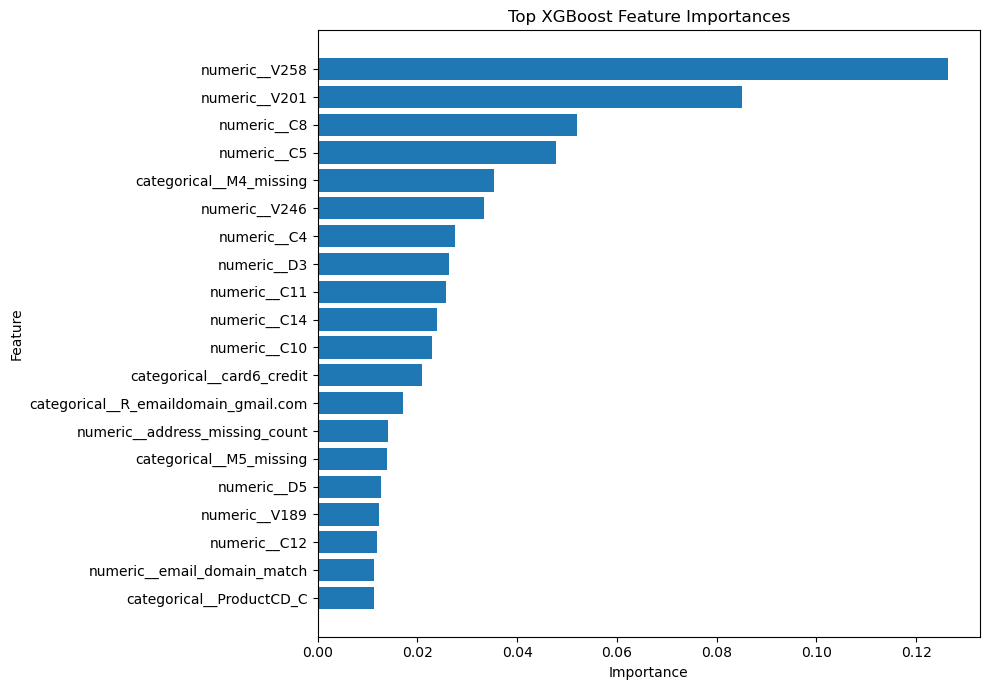

Feature importance figure saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\xgboost_feature_importance.png


,feature,importance
53,numeric__V258,0.126463
47,numeric__V201,0.085124
13,numeric__C8,0.051906
10,numeric__C5,0.047779
121,categorical__M4_missing,0.035383
51,numeric__V246,0.033293
9,numeric__C4,0.027549
22,numeric__D3,0.026291
16,numeric__C11,0.025669
19,numeric__C14,0.023967


In [15]:
def get_feature_names(model_pipeline: Pipeline) -> list[str]:
    preprocessor = model_pipeline.named_steps["preprocessor"]
    try:
        feature_names = preprocessor.get_feature_names_out()
        return [str(feature) for feature in feature_names]
    except Exception:
        return [
            f"feature_{index}"
            for index in range(len(model_pipeline.named_steps["classifier"].feature_importances_))
        ]


def plot_feature_importance(model_pipeline: Pipeline) -> pd.DataFrame:
    classifier = model_pipeline.named_steps["classifier"]
    feature_names = get_feature_names(model_pipeline)
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": classifier.feature_importances_,
        }
    ).sort_values("importance", ascending=False)
    top_features = importance_df.head(20).sort_values("importance")
    plt.figure(figsize=(10, 7))
    plt.barh(top_features["feature"], top_features["importance"])
    plt.title("Top XGBoost Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "xgboost_feature_importance.png")
    plt.show()
    return importance_df


importance_df = plot_feature_importance(model_pipeline)
print(f"Feature importance figure saved to: {FIGURES_DIR / 'xgboost_feature_importance.png'}")
importance_df.head(20)

## 13. Save the trained model

In [16]:
joblib.dump(model_pipeline, MODEL_FILE)
print(f"Model saved to: {MODEL_FILE}")

Model saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\ml\model_artifacts\xgboost_fraud_model.joblib


## 14. Summary

In [17]:
print("XGBoost Fraud Detection Model Report")
print("=" * 80)
print(f"scale_pos_weight: {scale_pos_weight:.3f}")
print()
print(metrics_df)
print()
print(f"Metrics saved to: {METRICS_FILE}")
print(f"Classification report saved to: {CLASSIFICATION_REPORT_FILE}")
print(f"Model saved to: {MODEL_FILE}")
print(f"Figures saved to: {FIGURES_DIR}")

XGBoost Fraud Detection Model Report
scale_pos_weight: 27.580

                     metric     value
0                  accuracy  0.863498
1                 precision  0.176445
2                    recall  0.790951
3                  f1_score  0.288526
4                   roc_auc  0.904650
5  average_precision_pr_auc  0.535844

Metrics saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\xgboost_model_metrics.csv
Classification report saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\xgboost_classification_report.txt
Model saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\ml\model_artifacts\xgboost_fraud_model.joblib
Figures saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures
